# Simulate progression under the new USATT ratings system

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

sns.set_theme()

from calculator import Player, Tournament

import sys
sys.path.insert(0, '../../load_data')
from load import load_stats, load_history

In [2]:
point_spread_bounds = [(0,12), (13,37), (38,62), (63,87), (88,112), (113,137), (138,162), (163,187), (188,212), (213,237), (238,np.inf)]
point_spread_index = pd.IntervalIndex.from_tuples(point_spread_bounds, closed="both")

expected_result_rating_change = [8, 7, 6, 5, 4, 3, 2, 2, 1, 1, 0]
upset_result_rating_change = [8, 10, 13, 16, 20, 25, 30, 35, 40, 45, 50]

rating_changes = pd.DataFrame(index=point_spread_index, data={"expected": expected_result_rating_change, "upset": upset_result_rating_change})

rating_changes['expected result per upset'] = rating_changes['upset'] / rating_changes['expected']
rating_changes['upset probability'] = 1 / (rating_changes['expected result per upset'] + 1)
rating_changes['expected probability'] = 1 - rating_changes['upset probability']

rating_changes['rating spread'] = rating_changes.index.left
rating_changes['lower rating spread'] = -rating_changes.index.left

lowerbound = -rating_changes['rating spread'].iloc[-1]
upperbound = rating_changes['rating spread'].iloc[-1]

x_axis = np.arange(lowerbound, upperbound)

x_bounds = rating_changes['lower rating spread'][::-1].to_list() + rating_changes['rating spread'].to_list()

## Theoretical Markov Chain

In [3]:
players = load_stats()
players = players[players['Tournament Rating'] != 0]

In [4]:
p_size = 3000
P = np.zeros((p_size, p_size))

rating_dist = players["Tournament Rating"]
total_rating_spread = rating_changes["rating spread"].iloc[-1]

for rating in range(p_size):
    potential_matches = pd.DataFrame({"rating": rating_dist[(rating - total_rating_spread < rating_dist) & (rating_dist < rating + total_rating_spread)]})

    bins = []
    for interval in rating_changes.index[::-1]:
        bins.append(pd.Interval(left=rating-interval.right, right=rating-interval.left, closed="both"))
    for interval in rating_changes.index:
        bins.append(rating + interval)

    n = len(rating_changes.index)
    bins[n-1] = pd.Interval(bins[n-1].left, bins[n-1].right-1, closed="both")

    bins = pd.IntervalIndex(bins)

    potential_matches['bin'] = pd.cut(potential_matches["rating"], bins=bins)

    match_counts = potential_matches.groupby("bin", observed=True).count()
    occurance_probabilities = match_counts / match_counts.sum()
    occurance_probabilities.rename(columns={"rating": "probability"}, inplace=True)

    win_probabilities = np.hstack([rating_changes["expected probability"][::-1], rating_changes["upset probability"]])
    lose_probabilities = 1 - win_probabilities
    win_probabilities = pd.Series(win_probabilities, index=bins)
    lose_probabilities = pd.Series(lose_probabilities, index=bins)

    match_probabilities = pd.DataFrame({"win probability": occurance_probabilities["probability"] * win_probabilities})
    match_probabilities["lose probability"] = occurance_probabilities['probability'] * lose_probabilities

    rating_change = pd.DataFrame(index=bins, data={"win rating change": expected_result_rating_change[::-1] + upset_result_rating_change, "lose rating change": upset_result_rating_change[::-1] + expected_result_rating_change})
    match_probabilities["win rating change"] = rating_change.loc[match_probabilities.index.mid, 'win rating change'].astype(int)
    match_probabilities["lose rating change"] = rating_change.loc[match_probabilities.index.mid, 'lose rating change'].astype(int)

    if abs(match_probabilities["win probability"].sum() + match_probabilities["lose probability"].sum() - 1 > 0.0001):
        print("sum error")
        break

    
    for i in range(len(match_probabilities)):
        transition_data = match_probabilities.iloc[i]

        if not np.isnan(transition_data["win probability"]):
            if rating + transition_data["win rating change"] >= p_size-1:
                P[rating, p_size-1] += transition_data["win probability"]
            else:
                P[rating, rating + int(transition_data["win rating change"])] += transition_data["win probability"]
        
        if not np.isnan(transition_data["lose probability"]):
            if rating - transition_data["lose rating change"] <= 0:
                P[rating, 0] += transition_data["lose probability"]
            else:
                P[rating, rating - int(transition_data["lose rating change"])] += transition_data["lose probability"]

KeyboardInterrupt: 

In [6]:
class MC:
    def __init__(self, s, p):
        self.states = s
        self.P = p

    def plot_pi(self, pi):
        sns.scatterplot(x=np.arange(0, p_size), y=pi, marker='.')
        plt.xlabel('rating')
        plt.ylabel('probability')
        plt.show()

    def n_step_transition_matrix(self, n):
        return np.linalg.matrix_power(P, n)

    def n_step_probability_distribution(self, init, n, plot=False):
        P_n = np.linalg.matrix_power(P, n)
        pi_n = init @ P_n

        if plot:
            self.plot_pi(pi_n)

        return pi_n

    def stationary_distribution(self, plot=False):
        n = self.P.shape[0]
        A = np.vstack([self.P.T - np.eye(n), np.ones(n)])
        b = np.append(np.zeros(n), 1)
        pi = np.linalg.lstsq(A, b, rcond=None)[0]

        if plot:
            self.plot_pi(pi)

        return pi

In [7]:
states = np.arange(0, p_size)

theoretical = MC(states, P)

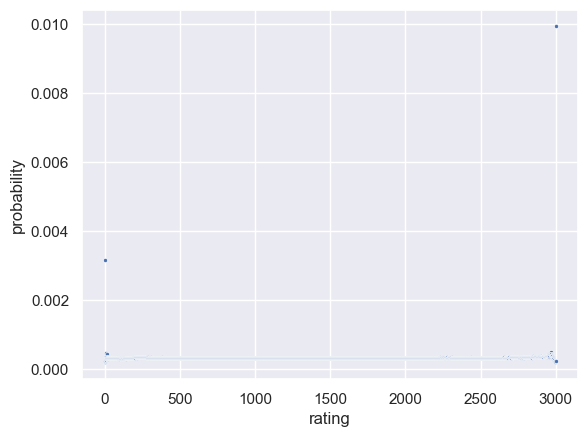

array([0.00315805, 0.00019612, 0.00022011, ..., 0.00023946, 0.0002265 ,
       0.00993867])

In [8]:
theoretical.stationary_distribution(plot=True)

## Simulated Markov Chain

In [4]:
from calculator import Player, Tournament

import random
from alive_progress import alive_bar

In [5]:
rating_counts = players['Tournament Rating'].value_counts()
rating_dist = rating_counts / rating_counts.sum()

In [6]:
sim_players = []

sim_player_count = 1000
for i in range(sim_player_count):
    sim_players.append(Player(id=i, rating=random.choices(rating_dist.index, weights=rating_dist.values)[0]))

In [7]:
def win_probability(rating_spread):
    return 1 / (1 + 10 ** (rating_spread / 121.37092754))

def simulate_tournament(sim_players, matches=10):
    sim_player_count = len(sim_players)

    for players in sim_players:
        if isinstance(players.rating, dict):
            raise ValueError("precheck")

    tournament = Tournament(sim_players)

    for player in sim_players:

        for i in range(matches):
            opponent = sim_players[random.randint(0, sim_player_count-1)]

            rating_spread = opponent.rating - player.rating
            win_prob = win_probability(rating_spread)
            lose_prob = 1 - win_prob

            possible_results = ["wins", "losses"]
            result = random.choices([0, 1], weights=[win_prob, lose_prob])[0]
            player_result = possible_results[result]
            opponent_result = possible_results[1 - result]

            tournament.all_results[player][player_result].append(opponent.rating)
            tournament.all_results[opponent][opponent_result].append(player.rating)

    return tournament

MSE: 1.620083922520836


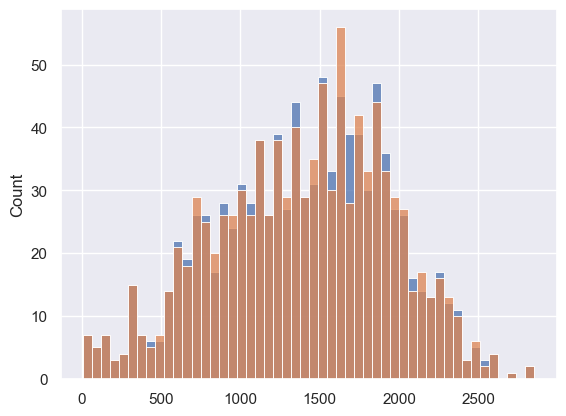

In [97]:

sim_players = []

sim_player_count = 1000
for i in range(sim_player_count):
    sim_players.append(Player(id=i, rating=random.choices(rating_dist.index, weights=rating_dist.values)[0]))

pre = pd.Series(index=np.arange(p_size), data=np.zeros(p_size))
preratings = pd.Series([player.rating for player in sim_players])
pre += preratings.value_counts()
pre.fillna(0, inplace=True)

tournament = simulate_tournament(sim_players)
tournament.full_pass()
sim_players = tournament.players

post = pd.Series(index=np.arange(p_size), data=np.zeros(p_size))
postratings = pd.Series([player.rating for player in sim_players])
post += postratings.value_counts()
post.fillna(0, inplace=True)

print(f"MSE: {np.sqrt(((pre - post) ** 2).sum() / (preratings.unique().size - 1))}")

sns.histplot(preratings, bins=50)
sns.histplot(postratings, bins=50)
plt.show()

In [141]:
sim_players = []

sim_player_count = 10000
for i in range(sim_player_count):
    sim_players.append(Player(id=i, rating=random.choices(rating_dist.index, weights=rating_dist.values)[0]))

avg_hist = []
mse_hist = []
diff_hist = []

p_size = 3000
P_counts = np.zeros((p_size, p_size))

tournament_count = 100

with alive_bar(tournament_count, force_tty=True) as bar:
    for i in range(tournament_count):
        pre = pd.Series(index=np.arange(p_size), data=np.zeros(p_size))
        preratings = pd.Series([player.rating for player in sim_players])
        pre += preratings.value_counts()
        pre.fillna(0, inplace=True)

        tournament = simulate_tournament(sim_players)
        tournament.full_pass()
        sim_players = tournament.players

        post = pd.Series(index=np.arange(p_size), data=np.zeros(p_size))
        postratings = pd.Series([player.rating for player in sim_players])
        post += postratings.value_counts()
        post.fillna(0, inplace=True)

        avg = postratings.mean()
        mse = np.sqrt(((pre - post) ** 2).sum() / (preratings.unique().size - 1))
        diff = ((pre - post).sum()) / (preratings.unique().size - 1)

        P_counts[preratings, postratings] += 1

        avg_hist.append(avg)
        mse_hist.append(mse)
        diff_hist.append(diff)

        bar()

P_counts_df = pd.DataFrame(P_counts)
P_counts_df.to_csv("./simulation_transitions/P_counts_1.2.csv", index=False)

|████████████████████████████████████████| 100/100 [100%] in 56:00.9 (0.03/s)   


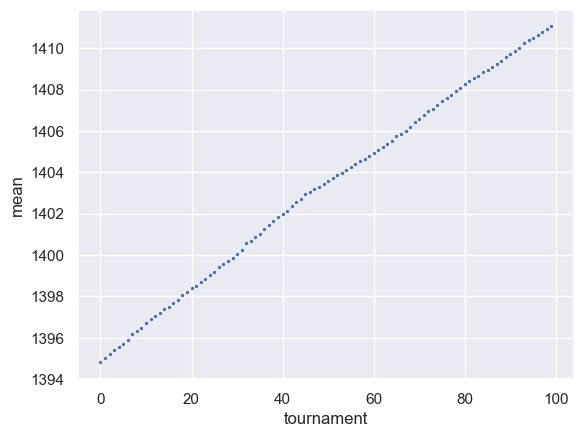

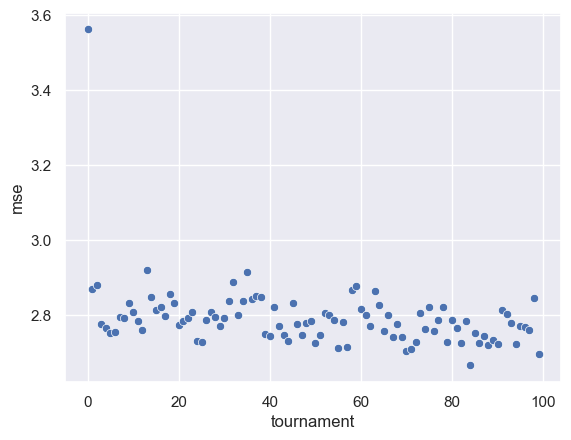

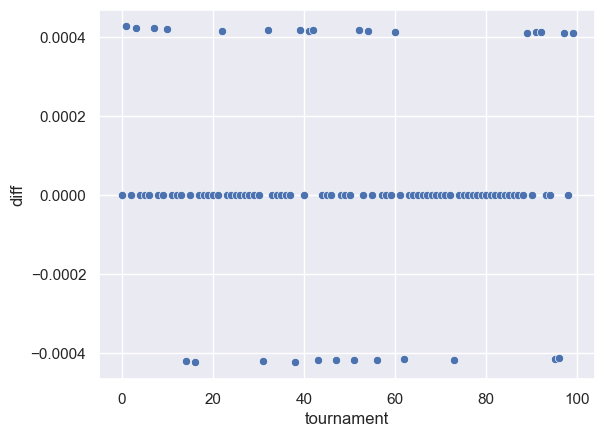

In [142]:
data = pd.DataFrame({"tournament": np.arange(tournament_count), "mean": avg_hist, "mse": mse_hist, "diff": diff_hist})

sns.scatterplot(data, x="tournament", y="mean", marker='.')
plt.show()
sns.scatterplot(data, x="tournament", y="mse")
plt.show()
sns.scatterplot(data, x="tournament", y="diff")
plt.show()

In [143]:
(np.array(diff_hist) != 0).sum()

29

In [161]:
M, N = P_counts.shape
K = 1
L = 1

MK = M // K
NL = N // L
test = P_counts[:MK*K, :NL*L].reshape(MK, K, NL, L).sum(axis=(1, 3))

In [149]:
t = test.sum(axis=1)
len(t[t == 0])

122

In [152]:
p1 = pd.read_csv("./simulation_transitions/P_counts_1.0.csv")
p2 = pd.read_csv("./simulation_transitions/P_counts_1.1.csv")
p3 = pd.read_csv("./simulation_transitions/P_counts_1.2.csv")

In [175]:
p = (p1 + p2 + p3).to_numpy()

M, N = p.shape
K = 1
L = 1

MK = M // K
NL = N // L
p = p[:MK*K, :NL*L].reshape(MK, K, NL, L).sum(axis=(1, 3))

In [181]:
t = p.sum(axis=1)
len(t[t==0])

72

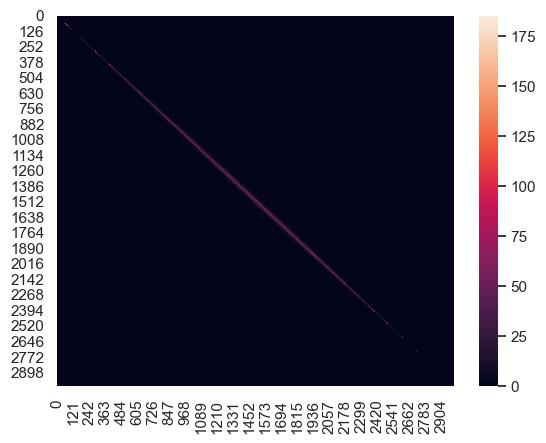

In [176]:
sns.heatmap(p)
plt.show()

In [5]:
data = pd.read_csv("./major_tournament_history_data/simulation_history_20_matches_2_0.csv")

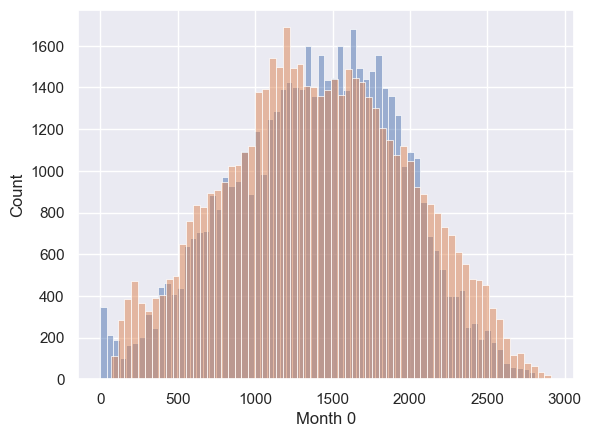

In [14]:
sns.histplot(data=data, x="Month 0", alpha=0.5)
sns.histplot(data=data, x="Month 120", alpha=0.5)
plt.show()

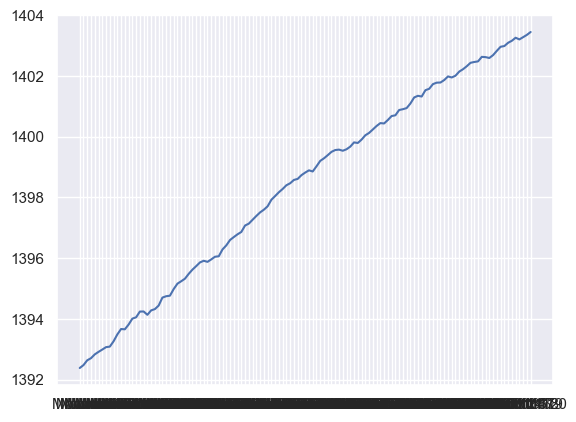

In [21]:
sns.lineplot(data=data.mean(axis=0))
plt.show()

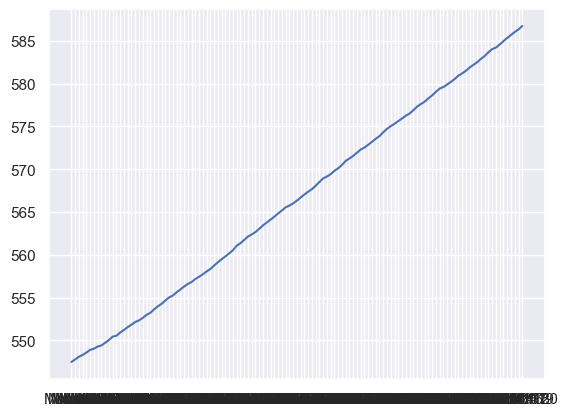

In [24]:
sns.lineplot(data=data.std(axis=0))
plt.show()